# Artists on fxhash

How many different artists published generative projects on fxhash, and how
unevenly the work is spread across them. Identity here is the **wallet address**
(`author_id`); `author_name` is the display name. All numbers come from
`data/fxhash_tokens.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

IMG = Path("docs/img")
IMG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("data/fxhash_tokens.csv")
df["minted"] = pd.to_numeric(df["iterations_count"], errors="coerce").fillna(0)

# One row per artist (wallet); fall back to a short wallet when the name is blank.
art = df.groupby("author_id").agg(
    name=("author_name", "first"),
    projects=("id", "size"),
    editions=("minted", "sum"),
).reset_index()
art["label"] = art["name"].fillna(art["author_id"].str[:8])
len(art)

5741

## Headline numbers

In [2]:
one = int((art["projects"] == 1).sum())
print(f"distinct artists (wallets):  {df['author_id'].nunique():,}")
print(f"distinct display names:      {df['author_name'].nunique():,}")
print(f"median projects per artist:  {art['projects'].median():.0f}")
print(f"mean projects per artist:    {art['projects'].mean():.2f}")
print(f"max (single artist):         {int(art['projects'].max()):,}")
print(f"artists with just 1 project: {one:,} ({100*one/len(art):.0f}%)")
print()
print("artists per version:")
print(df.groupby("version")["author_id"].nunique().to_string())

distinct artists (wallets):  5,741
distinct display names:      4,593
median projects per artist:  2
mean projects per artist:    4.91
max (single artist):         412
artists with just 1 project: 2,624 (46%)

artists per version:
version
fxhash 1.0 (Tezos)    5407
fxhash 2.0 (EVM)       334


## How many projects each artist published

Almost half published a single project; a small group is very prolific.

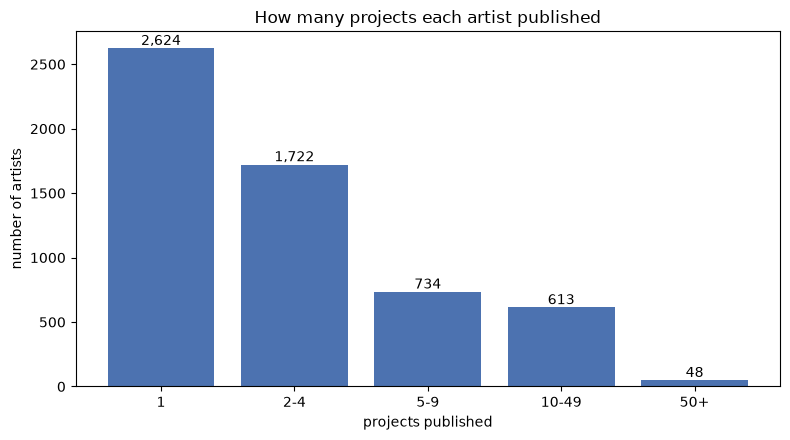

In [3]:
bins = [1, 2, 5, 10, 50, float("inf")]
labels = ["1", "2-4", "5-9", "10-49", "50+"]
buckets = pd.cut(art["projects"], bins=bins, right=False, labels=labels)
counts = buckets.value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(counts.index, counts.values, color="#4c72b0")
ax.set_xlabel("projects published")
ax.set_ylabel("number of artists")
ax.set_title("How many projects each artist published")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{int(v):,}", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(IMG / "artists_projects_per.png", dpi=110)
plt.show()

## Most prolific artists (by number of projects)

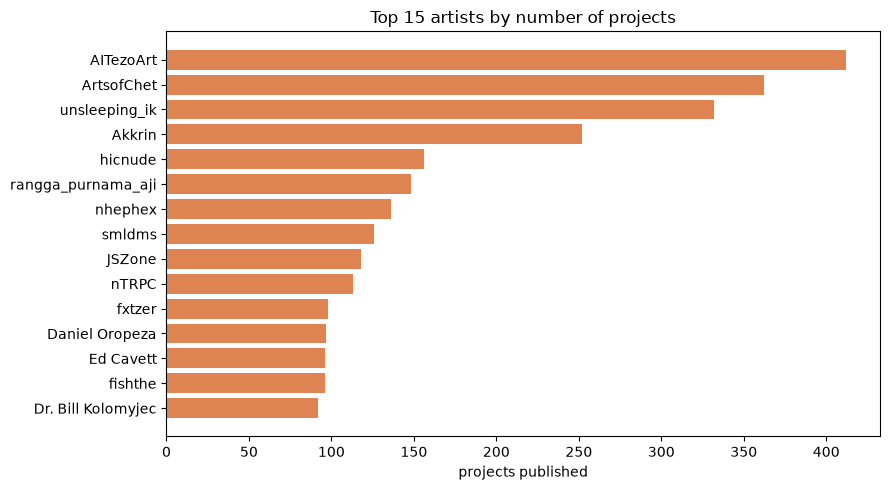

In [4]:
top = art.nlargest(15, "projects")[["label", "projects"]][::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top["label"], top["projects"], color="#dd8452")
ax.set_xlabel("projects published")
ax.set_title("Top 15 artists by number of projects")
fig.tight_layout()
fig.savefig(IMG / "artists_top_projects.png", dpi=110)
plt.show()

## Most collected artists (by editions minted)

A different ranking: whose work was minted the most, regardless of project count.

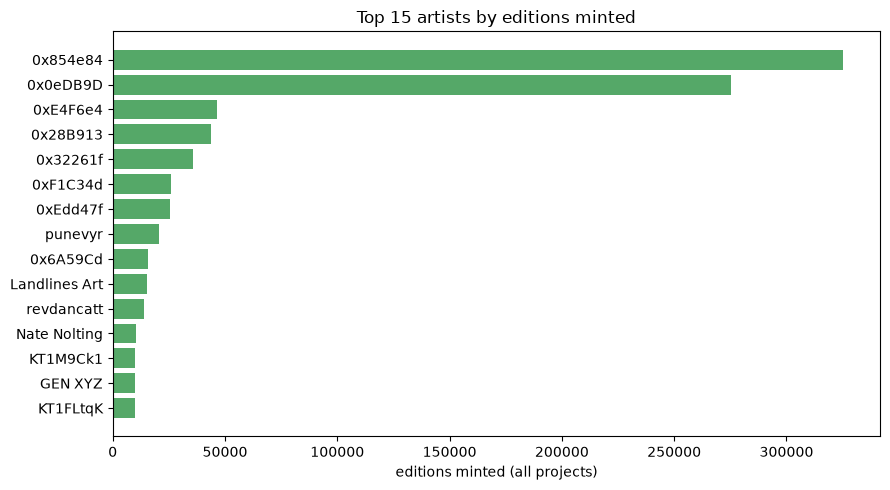

In [5]:
tope = art.nlargest(15, "editions")[["label", "editions"]][::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(tope["label"], tope["editions"], color="#55a868")
ax.set_xlabel("editions minted (all projects)")
ax.set_title("Top 15 artists by editions minted")
fig.tight_layout()
fig.savefig(IMG / "artists_top_editions.png", dpi=110)
plt.show()